## import libraries

In [369]:
# import libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import os

## read shapefiles of datasets

In [408]:
# defining the paths
austria_path = "_data/eurocrops_original_data/AT_2021"
portugal_path = "_data/eurocrops_original_data/PT_2021"
sweden_path = "_data/eurocrops_original_data/SE_2021"
spain_path = "_data/eurocrops_original_data/ES_2020"
ireland_path = "_data/eurocrops_original_data/IE_2023"
france_path = "_data/eurocrops_original_data/FR_2018"

In [ ]:
# read shapefiles
austria = gpd.read_file(austria_path)
sweden = gpd.read_file(sweden_path)
portugal = gpd.read_file(portugal_path)
spain = gpd.read_file(spain_path)
ireland = gpd.read_file(ireland_path)
france = gpd.read_file(france_path)

## select columns of interest

In [390]:
countries_list = [austria, sweden, portugal, spain, ireland, france]
country_names = ['austria_2021', 'sweden_2021', 'portugal_2021', 'spain_2020', 'ireland_2023', 'france_2018']
columns = ['EC_hcat_n', 'EC_hcat_c', 'geometry']

In [391]:
# select only the columns of interest

def interest_columns(gdp, columns):
    return gdp[columns]

for i in range(len(countries_list)):
    countries_list[i] = interest_columns(countries_list[i], columns)

## select crops of interest

In [392]:
# # count the most occurent classes
# print(f"Austria most common classes: {austria["EC_hcat_n"].value_counts()[:12]} \n")
# print(f"Sweden most common classes: {sweden["EC_hcat_n"].value_counts()[:12]} \n")
# print(f"Portugal most common classes: {portugal["EC_hcat_n"].value_counts()[:12]} \n")
# print(f"Spain most common classes: {spain["EC_hcat_n"].value_counts()[:20]} \n")
# print(f"Ireland most common classes: {ireland["EC_hcat_n"].value_counts()[:12]} \n")
# print(f"France most common classes: {france["EC_hcat_n"].value_counts()[:12]} \n")

In [393]:
# define the crop of interest

crops = ['clover', 'potatoes', 'orchards_fruits', 'rye']

def interest_crop(gdp, crop):
    result = gdp[gdp['EC_hcat_n'] == crop]
    return result, result.size

In [394]:
# create dataset per country per crop

datasets = {}

for gdf, c_name in zip(countries_list, country_names):
    for crop in crops:
        var_name = f"{crop}_{c_name}"
        
        subset_gdf, subset_size = interest_crop(gdf, crop)
        
        if subset_size > 0:
            datasets[var_name] = subset_gdf
            
        else:
            continue

In [395]:
country_crop = []

for i in datasets.keys():
    country_crop.append(i)

In [396]:
print(f"Number of datasets created: {len(datasets)}")
print(f"Datasets created: {datasets.keys()}")

Number of datasets created: 20
Datasets created: dict_keys(['clover_austria_2021', 'potatoes_austria_2021', 'orchards_fruits_austria_2021', 'rye_austria_2021', 'clover_sweden_2021', 'potatoes_sweden_2021', 'orchards_fruits_sweden_2021', 'rye_sweden_2021', 'clover_portugal_2021', 'potatoes_portugal_2021', 'orchards_fruits_portugal_2021', 'rye_portugal_2021', 'orchards_fruits_spain_2020', 'clover_ireland_2023', 'potatoes_ireland_2023', 'orchards_fruits_ireland_2023', 'rye_ireland_2023', 'clover_france_2018', 'potatoes_france_2018', 'orchards_fruits_france_2018'])


## get centroid and long and lat

In [397]:
# accessing coordinates
def access_coords(gpd, index):
    poligon = gpd.geometry.iloc[index]

    coords = list(poligon.exterior.coords)

    coords_numpy = np.array(poligon.exterior.coords)
    return poligon, coords, coords_numpy

In [398]:
# get centorid and transform coordinates to lat and long
def get_centroid(gdp, centroid_as_main=False):
    gdp = gdp.copy()
    gdp['centroid'] = gdp.geometry.to_crs(gdp.estimate_utm_crs()).centroid.to_crs(epsg=4326)
    # gdp['centroid'] = gdp.geometry.centroid.to_crs(epsg=4326)
    gdp = gdp.to_crs(epsg=4326)
    if centroid_as_main == True: 
        gdp = gdp.set_geometry('centroid')
    return gdp

In [399]:
# get correct format for long and lat
def get_long_lat(gdp):
    gdp['long'] = gdp['centroid'].apply(lambda p: p.x)
    gdp['lat'] = gdp['centroid'].apply(lambda p: p.y)
    return gdp

In [400]:
# check before applying transformations
print(datasets['orchards_fruits_portugal_2021'].crs)
datasets['orchards_fruits_portugal_2021'].head(3)

EPSG:4326


,EC_hcat_n,EC_hcat_c,geometry
65,orchards_fruits,3303010000,"POLYGON ((-7.38032 40.30368, -7.38032 40.30369..."
70,orchards_fruits,3303010000,"POLYGON ((-8.50154 40.5778, -8.50178 40.57776,..."
88,orchards_fruits,3303010000,"POLYGON ((-8.50144 40.59508, -8.50143 40.59508..."


In [401]:
for i in country_crop:
    print(f"Apply functions on {i}")
    datasets[i] = get_centroid(datasets[i])
    datasets[i] = get_long_lat(datasets[i])

Apply functions on clover_austria_2021
Apply functions on potatoes_austria_2021
Apply functions on orchards_fruits_austria_2021
Apply functions on rye_austria_2021
Apply functions on clover_sweden_2021
Apply functions on potatoes_sweden_2021
Apply functions on orchards_fruits_sweden_2021
Apply functions on rye_sweden_2021
Apply functions on clover_portugal_2021
Apply functions on potatoes_portugal_2021
Apply functions on orchards_fruits_portugal_2021
Apply functions on rye_portugal_2021
Apply functions on orchards_fruits_spain_2020
Apply functions on clover_ireland_2023
Apply functions on potatoes_ireland_2023
Apply functions on orchards_fruits_ireland_2023
Apply functions on rye_ireland_2023
Apply functions on clover_france_2018
Apply functions on potatoes_france_2018
Apply functions on orchards_fruits_france_2018


In [402]:
# check after applying transformations
print(datasets['orchards_fruits_portugal_2021'].crs)
datasets['orchards_fruits_portugal_2021'].head(3)

EPSG:4326


,EC_hcat_n,EC_hcat_c,geometry,centroid,long,lat
65,orchards_fruits,3303010000,"POLYGON ((-7.38032 40.30368, -7.38032 40.30369...",POINT (-7.38004 40.30352),-7.380043,40.303520
70,orchards_fruits,3303010000,"POLYGON ((-8.50154 40.5778, -8.50178 40.57776,...",POINT (-8.50135 40.57796),-8.501346,40.577960
88,orchards_fruits,3303010000,"POLYGON ((-8.50144 40.59508, -8.50143 40.59508...",POINT (-8.50159 40.5952),-8.501591,40.595203


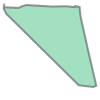

In [405]:
access_coords(datasets['orchards_fruits_portugal_2021'], 0)[0]

## export data

In [406]:
export_folder = "_data/crop_country_exports"

if not os.path.exists(export_folder):
    os.makedirs(export_folder)
    print(f"Created directory: {export_folder}")

for name in datasets.keys():
    temp_df = pd.DataFrame(datasets[name][['EC_hcat_n', 'EC_hcat_c', 'long', 'lat']]).copy()
    
    file_path = f"{export_folder}/{name}.csv"
    
    temp_df.to_csv(file_path, index=False)
    print(f"Exported: {file_path}")

Exported: _data/crop_country_exports/clover_austria_2021.csv
Exported: _data/crop_country_exports/potatoes_austria_2021.csv
Exported: _data/crop_country_exports/orchards_fruits_austria_2021.csv
Exported: _data/crop_country_exports/rye_austria_2021.csv
Exported: _data/crop_country_exports/clover_sweden_2021.csv
Exported: _data/crop_country_exports/potatoes_sweden_2021.csv
Exported: _data/crop_country_exports/orchards_fruits_sweden_2021.csv
Exported: _data/crop_country_exports/rye_sweden_2021.csv
Exported: _data/crop_country_exports/clover_portugal_2021.csv
Exported: _data/crop_country_exports/potatoes_portugal_2021.csv
Exported: _data/crop_country_exports/orchards_fruits_portugal_2021.csv
Exported: _data/crop_country_exports/rye_portugal_2021.csv
Exported: _data/crop_country_exports/orchards_fruits_spain_2020.csv
Exported: _data/crop_country_exports/clover_ireland_2023.csv
Exported: _data/crop_country_exports/potatoes_ireland_2023.csv
Exported: _data/crop_country_exports/orchards_fruits